## Drive & imports

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os
from datetime import datetime


# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import os
import cv2
import numpy as np
import glob
import json

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch, gc
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
!pip install torchview
from torchview import draw_graph
import torch.optim as optim


# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.gridspec as gridspec


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cpu
Device: cpu


In [3]:
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.8 MB/s eta 0:00:00


## Test data loading

In [4]:
# @title Load test images

def load_test_images(
    csv_path,
    images_dir
):
    df = pd.read_csv(csv_path)
    df_test = df[df["split"] == "test"].reset_index(drop=True)

    X = []
    filenames = []

    print(f"Caricamento {len(df_test)} immagini di test")

    for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
        fname = row["filename"]
        img_path = os.path.join(images_dir, fname)

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            print(f"⚠️ Immagine non trovata: {fname}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        filenames.append(fname)

    X = np.array(X)

    print("\n Test set caricato")
    print(f"   X shape      : {X.shape}")
    print(f"   # filenames  : {len(filenames)}")

    return X, filenames


In [5]:
# @title CLAHE fun
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_grayscale_and_clahe(X):
    """
    1. Converte immagini RGB in Grayscale.
    2. Applica CLAHE con parametri da paper (ClipLimit=4.0, Grid=8x8).

    Input: Array (N, H, W, 3) o (N, H, W)
    Output: Array (N, H, W, 1) pronto per la rete.
    """
    print(f"Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...")

    # Inizializza l'oggetto CLAHE con i parametri richiesti
    # clipLimit=4.0 rende il contrasto molto forte (utile per bordi tumorali)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))

    X_processed = []

    for i in range(len(X)):
        img = X[i]

        # --- CHECK VALIDITÀ (UINT8) ---
        # OpenCV CLAHE lavora su uint8 (0-255). Se i dati sono float 0-1, convertiamo.
        if img.dtype == 'float32' or img.dtype == 'float64':
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        # --- 1. CONVERSIONE GRAYSCALE ---
        # Se l'immagine ha 3 canali, la convertiamo. Se ne ha già 1 o 0 (flat), saltiamo.
        if len(img.shape) == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            # Se è già in scala di grigi (es. 256, 256) o (256, 256, 1)
            gray = img
            if len(gray.shape) == 3: # Rimuovi dimensione canale inutile se c'è
                gray = gray[:, :, 0]

        # --- 2. APPLICAZIONE CLAHE ---
        img_clahe = clahe.apply(gray)

        X_processed.append(img_clahe)

    # Conversione in array Numpy
    X_processed = np.array(X_processed)

    # --- RESHAPE FINALE ---
    # Le reti (come U-Net o ResNet) si aspettano un canale esplicito: (N, 256, 256, 1)
    # Attualmente X_processed è (N, 256, 256)
    X_final = np.expand_dims(X_processed, axis=-1)

    print(f"Processamento completato.")
    print(f"   Shape finale: {X_final.shape}")

    return X_final

In [6]:
CSV_PATH = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/Test.csv"
IMG_DIR  = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/images"

X_test_raw, test_filenames = load_test_images(
    csv_path=CSV_PATH,
    images_dir=IMG_DIR
)

Caricamento 119 immagini di test


  0%|          | 0/119 [00:00<?, ?it/s]


 Test set caricato
   X shape      : (119, 256, 256, 3)
   # filenames  : 119


Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...
Processamento completato.
   Shape finale: (119, 256, 256, 1)


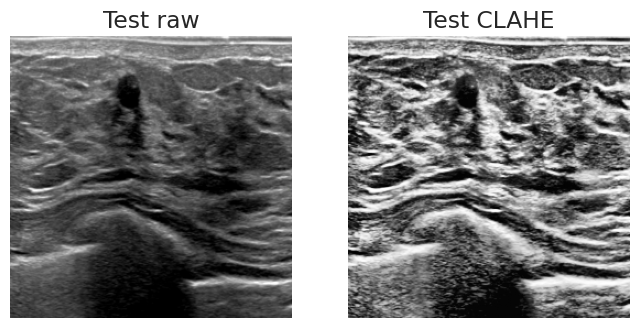

In [7]:
# same preprocessing as for training
X_test_clahe = apply_grayscale_and_clahe(X_test_raw)

# visualization

idx = np.random.randint(0, len(X_test_clahe))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_test_raw[idx])
plt.title("Test raw")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_test_clahe[idx].squeeze(), cmap="gray")
plt.title("Test CLAHE")
plt.axis("off")

plt.show()



## Segmentation model

In [9]:
# @title Helper functions

""" Per recuperare le cartelle """

def get_fold_paths_simple(MODELS_DIR, run_name, fold_id):
    run_dir = os.path.join(MODELS_DIR, run_name)
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    return {
        "run_dir": run_dir,
        "fold_dir": fold_dir,
        "best_path": os.path.join(fold_dir, "best.pth"),
        "history_csv": os.path.join(fold_dir, "history.csv"),
        "metrics_json": os.path.join(fold_dir, "metrics.json"),
    }


""" FUnzione per richiamare il modello passando il nome dell'architettura, per poterlo usare in più prove """

def make_model_segm(arch, encoder_name, encoder_weights, in_channels, classes, device):
    arch = arch.lower()
    if arch in ["unet++", "unetplusplus", "unetpp"]:
        model_cls = smp.UnetPlusPlus
    elif arch in ["unet"]:
        model_cls = smp.Unet
    elif arch in ["deeplabv3plus", "deeplabv3+"]:
        model_cls = smp.DeepLabV3Plus
    elif arch in ["fpn"]:
        model_cls = smp.FPN
    else:
        raise ValueError(f"Architettura non supportata: {arch}")

    model = model_cls(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        activation=None
    ).to(device)

    return model

# @title helper per ricaricare pesi
def load_best_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    return ckpt

# @title helper per creare path salvataggio pesi

def get_ckpt_paths(run_dir, fold_id):
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    best_path = os.path.join(fold_dir, "best.pth")
    return best_path



In [10]:
# -------------------------------
# Caricamento modello
# -------------------------------


MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS"
run_name   = "UnetPlusPlus_effb4_retrainTrainVal_35"

CKPT_PATH = os.path.join(
    MODELS_DIR,
    run_name,
    "retrain_trainval/"
    "best.ckpt"
)

model_cfg = {
  "arch": "unetpp",
  "encoder_name": "efficientnet-b4",
  "encoder_weights": "imagenet",
  "in_channels": 1,
  "classes": 1
}


model = make_model_segm(
    arch=model_cfg["arch"],
    encoder_name=model_cfg["encoder_name"],
    encoder_weights=None,
    in_channels=model_cfg["in_channels"],
    classes=model_cfg["classes"],
    device=device
)

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(
    ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
)
model.eval()

print("Modello caricato!")


Modello caricato!


In [11]:
# @title Run segmentation inference

from tqdm import tqdm
import torch
import numpy as np

def run_segmentation_inference(
    model,
    X,
    device,
    thr=0.5
):
    preds = []
    model.eval()

    with torch.no_grad():
        for i in tqdm(range(len(X)), desc="Inferenza segmentazione"):
            img = X[i]  # (H,W,1) uint8
            x = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0).to(device)

            # ✅ MATCH training: [0,255] -> [0,1]
            x = x / 255.0

            logits = model(x)
            prob = torch.sigmoid(logits)
            mask = (prob > thr).to(torch.uint8)  # 0/1

            preds.append(mask.squeeze().cpu().numpy())

    return preds




In [12]:
# -------------------------------
# Inference su test set
# -------------------------------

pred_masks = run_segmentation_inference(
    model=model,
    X=X_test_clahe,
    device=device,
    thr=0.5
)


Inferenza segmentazione: 100%|██████████| 119/119 [02:04<00:00,  1.05s/it]


In [13]:
# @title Save pred masks

"""
Struttura di salvataggio:
Nota bene - la maschera viene salvata con lo stesso nome del filename (non con l'indice come avveniva durante il training)

PRED_MASKS_INFERENCE/
 ├── 18.png
 ├── 27.png
 └── 34.png

"""

import cv2

OUT_MASK_DIR = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/PRED_MASKS_INFERENCE"
os.makedirs(OUT_MASK_DIR, exist_ok=True)

for mask, fname in zip(pred_masks, test_filenames):
    out_path = os.path.join(OUT_MASK_DIR, fname)
    cv2.imwrite(out_path, mask * 255)

print(f"Salvate {len(pred_masks)} maschere in {OUT_MASK_DIR}")


Salvate 119 maschere in /content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/PRED_MASKS_INFERENCE


Calcolo metriche su test: 100%|██████████| 119/119 [00:37<00:00,  3.20it/s]



SUMMARY — TEST SET (Segmentation)
N GT test (csv) : 119
N evaluated     : 119
Missing images  : 0
Missing GT masks: 0
Missing Pred    : 0
Dice  mean      : 0.7825
Dice  median    : 0.9112
IoU   mean      : 0.7157
IoU   median    : 0.8369

--- NORMAL (GT label=2) ---
N         : 24
Dice mean : 0.8750
IoU  mean : 0.8750

--- TUMOR (GT label!=2) ---
N         : 95
Dice mean : 0.7591
IoU  mean : 0.6754

Esempi selezionati (2 per classe):
Benign ['348.png', '349.png']
Malignant ['139.png', '140.png']
Normal ['18.png', '27.png']


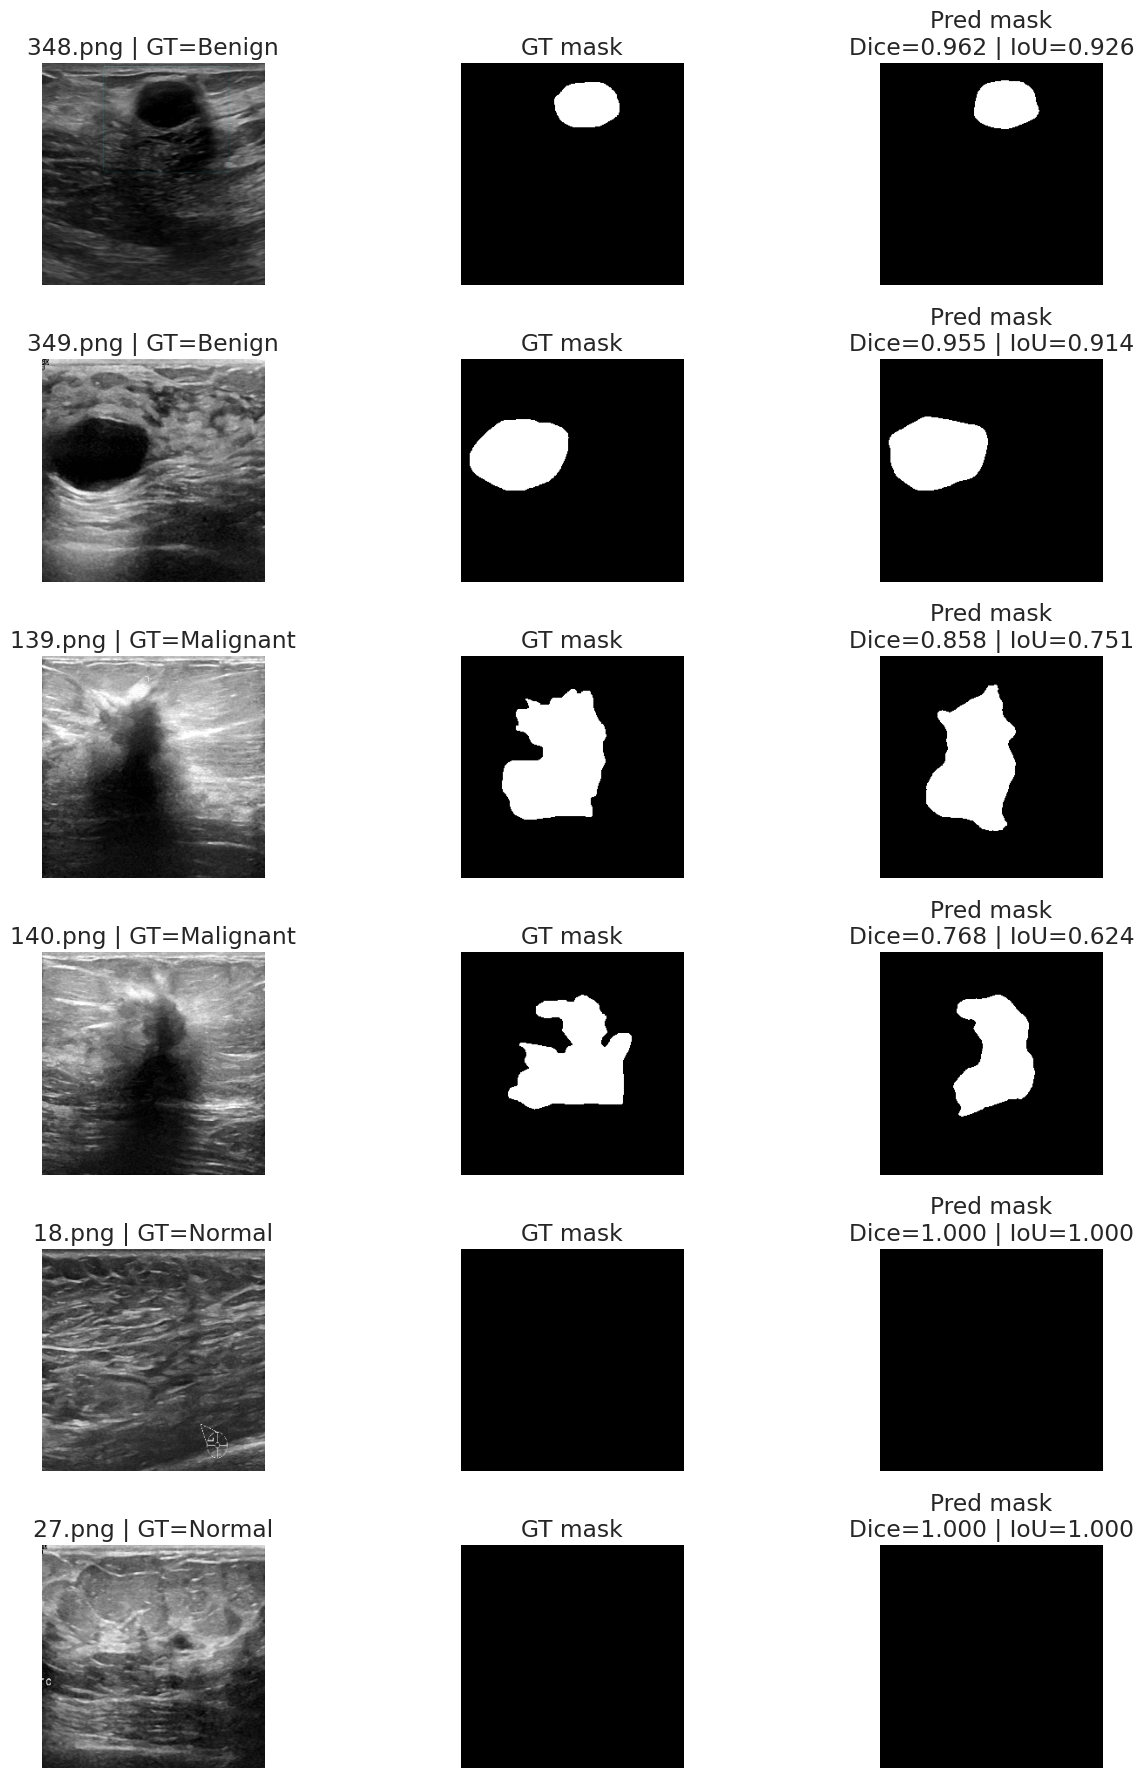

In [14]:
# @title Confronto con GT (6 esempi: 2 per classe) + SUMMARY (test set)

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

# --- PATHS ---
GT_CSV      = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/Test.csv"
IMAGES_DIR  = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/images"
GT_MASK_DIR = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/masks"
PRED_DIR    = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/PRED_MASKS_INFERENCE"

# --- helper metriche ---
def dice_iou(gt, pr, eps=1e-8):
    gt = gt.astype(bool)
    pr = pr.astype(bool)
    inter = np.logical_and(gt, pr).sum()
    union = np.logical_or(gt, pr).sum()
    dice = (2 * inter + eps) / (gt.sum() + pr.sum() + eps)
    iou  = (inter + eps) / (union + eps)
    return float(dice), float(iou)

def read_mask_bin(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        return None
    return (m > 0).astype(np.uint8)

# --- load GT test list ---
df = pd.read_csv(GT_CSV)
df = df[df["split"] == "test"].reset_index(drop=True)

label_map = {0: "Benign", 1: "Malignant", 2: "Normal"}

# =========================
# (A) SUMMARY su tutto il test
# =========================
rows = []
missing_img = missing_gt = missing_pred = 0

for fname in tqdm(df["filename"].tolist(), desc="Calcolo metriche su test"):
    img_path  = os.path.join(IMAGES_DIR, fname)
    gt_path   = os.path.join(GT_MASK_DIR, fname)
    pred_path = os.path.join(PRED_DIR, fname)

    if not os.path.exists(img_path):
        missing_img += 1
        continue

    gt_bin = read_mask_bin(gt_path)
    if gt_bin is None:
        missing_gt += 1
        continue

    pr_bin = read_mask_bin(pred_path)
    if pr_bin is None:
        missing_pred += 1
        continue

    d, j = dice_iou(gt_bin, pr_bin)
    rows.append({"filename": fname, "dice": d, "iou": j})

res_df = pd.DataFrame(rows)

print("\n==============================")
print("SUMMARY — TEST SET (Segmentation)")
print("==============================")
print(f"N GT test (csv) : {len(df)}")
print(f"N evaluated     : {len(res_df)}")
print(f"Missing images  : {missing_img}")
print(f"Missing GT masks: {missing_gt}")
print(f"Missing Pred    : {missing_pred}")
if len(res_df) > 0:
    print(f"Dice  mean      : {res_df['dice'].mean():.4f}")
    print(f"Dice  median    : {res_df['dice'].median():.4f}")
    print(f"IoU   mean      : {res_df['iou'].mean():.4f}")
    print(f"IoU   median    : {res_df['iou'].median():.4f}")

# Tumor vs Normal (usando la label GT dal CSV)
dfm = df.merge(res_df, on="filename", how="inner")
df_normal = dfm[dfm["label"] == 2]
df_tumor  = dfm[dfm["label"] != 2]

if len(dfm) > 0:
    print("\n--- NORMAL (GT label=2) ---")
    print(f"N         : {len(df_normal)}")
    if len(df_normal) > 0:
        print(f"Dice mean : {df_normal['dice'].mean():.4f}")
        print(f"IoU  mean : {df_normal['iou'].mean():.4f}")

    print("\n--- TUMOR (GT label!=2) ---")
    print(f"N         : {len(df_tumor)}")
    if len(df_tumor) > 0:
        print(f"Dice mean : {df_tumor['dice'].mean():.4f}")
        print(f"IoU  mean : {df_tumor['iou'].mean():.4f}")

# =========================
# (B) 6 esempi: 2 per classe GT
# =========================
samples = defaultdict(list)
for _, row in df.iterrows():
    lbl = int(row["label"])
    if len(samples[lbl]) < 2:
        samples[lbl].append(row["filename"])

print("\nEsempi selezionati (2 per classe):")
for k in [0, 1, 2]:
    print(label_map[k], samples[k])

plt.figure(figsize=(14, 18))
plot_idx = 1

for lbl in [0, 1, 2]:
    for fname in samples[lbl]:

        img_path  = os.path.join(IMAGES_DIR, fname)
        gt_path   = os.path.join(GT_MASK_DIR, fname)
        pred_path = os.path.join(PRED_DIR, fname)

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            # se manca, metto riga vuota ma non rompo tutto
            for _ in range(3):
                plt.subplot(6, 3, plot_idx); plt.axis("off"); plot_idx += 1
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        gt_bin = read_mask_bin(gt_path)
        pr_bin = read_mask_bin(pred_path)

        if gt_bin is None or pr_bin is None:
            # se manca gt/pred, metto comunque immagine + placeholder
            plt.subplot(6, 3, plot_idx); plt.imshow(img_rgb); plt.title(f"{fname} | GT={label_map[lbl]}"); plt.axis("off"); plot_idx += 1
            plt.subplot(6, 3, plot_idx); plt.text(0.5, 0.5, "GT missing", ha="center", va="center"); plt.axis("off"); plot_idx += 1
            plt.subplot(6, 3, plot_idx); plt.text(0.5, 0.5, "Pred missing", ha="center", va="center"); plt.axis("off"); plot_idx += 1
            continue

        d, j = dice_iou(gt_bin, pr_bin)

        # Original
        plt.subplot(6, 3, plot_idx)
        plt.imshow(img_rgb)
        plt.title(f"{fname} | GT={label_map[lbl]}")
        plt.axis("off")
        plot_idx += 1

        # GT mask
        plt.subplot(6, 3, plot_idx)
        plt.imshow(gt_bin, cmap="gray")
        plt.title("GT mask")
        plt.axis("off")
        plot_idx += 1

        # Pred mask
        plt.subplot(6, 3, plot_idx)
        plt.imshow(pr_bin, cmap="gray")
        plt.title(f"Pred mask\nDice={d:.3f} | IoU={j:.3f}")
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()


## Prepare classification input

In [15]:
# @title Preprocessed image + mask

def build_cls_input_images(
    X_clahe,
    filenames,
    pred_mask_dir,
    out_dir
):
    assert len(X_clahe) == len(filenames)

    for i, fname in tqdm(enumerate(filenames), total=len(filenames),
                          desc=" Costruzione input classificatore"):

        # --- immagine CLAHE ---
        img = X_clahe[i].squeeze()   # (H, W)

        # --- maschera predetta ---
        mask_path = os.path.join(pred_mask_dir, fname)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print(f" Maschera mancante: {fname}")
            continue

        # binarizzazione di sicurezza (0/1)
        mask_bin = (mask > 0).astype(np.uint8)

        # --- overlay (mask * image) ---
        cls_img = img * mask_bin

        # --- salvataggio ---
        out_path = os.path.join(out_dir, fname)
        cv2.imwrite(out_path, cls_img)

    print(f"\n Immagini per classificazione salvate in:\n{out_dir}")


In [16]:
PRED_MASK_DIR = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/PRED_MASKS_INFERENCE"
CLS_OUT_DIR   = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/CLS_INPUT_IMAGES_INFERENCE"

os.makedirs(CLS_OUT_DIR, exist_ok=True)

build_cls_input_images(
    X_clahe=X_test_clahe,
    filenames=test_filenames,
    pred_mask_dir=PRED_MASK_DIR,
    out_dir=CLS_OUT_DIR
)

 Costruzione input classificatore: 100%|██████████| 119/119 [00:02<00:00, 41.82it/s]


 Immagini per classificazione salvate in:
/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/CLS_INPUT_IMAGES_INFERENCE


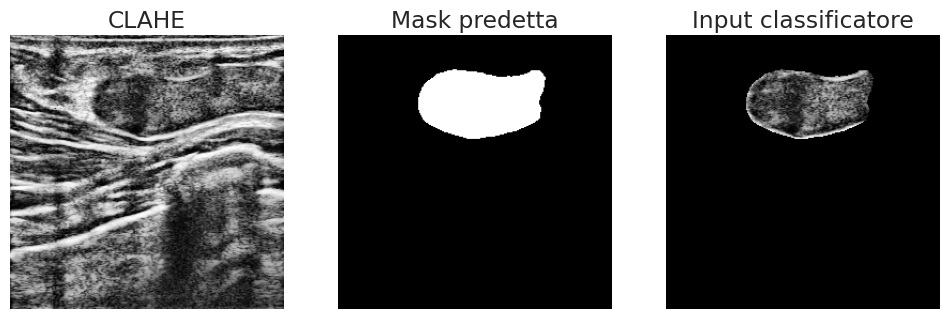

In [17]:
idx = np.random.randint(0, len(test_filenames))
fname = test_filenames[idx]

img = X_test_clahe[idx].squeeze()
mask = cv2.imread(os.path.join(PRED_MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)
cls  = cv2.imread(os.path.join(CLS_OUT_DIR, fname), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask predetta")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cls, cmap="gray")
plt.title("Input classificatore")
plt.axis("off")

plt.show()


In [18]:
# @title Filter images with all black mask (implicitly classified as Normal)

def split_normal_vs_tumor_images(
    cls_input_dir,
    filenames
):
    normal_files = []
    tumor_files  = []

    for fname in tqdm(filenames, desc="🔍 Filtro NORMAL vs TUMOR"):
        img_path = os.path.join(cls_input_dir, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"⚠️ Immagine mancante: {fname}")
            continue

        if np.all(img == 0):
            normal_files.append(fname)
        else:
            tumor_files.append(fname)

    print("\n Split risultati:")
    print(f"   NORMAL : {len(normal_files)}")
    print(f"   TUMOR  : {len(tumor_files)}")

    return normal_files, tumor_files




In [19]:
CLS_INPUT_DIR = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/CLS_INPUT_IMAGES_INFERENCE"

normal_files, tumor_files = split_normal_vs_tumor_images(
    CLS_INPUT_DIR,
    test_filenames
)

pred_rows = []

for fname in normal_files:
    pred_rows.append({
        "filename": fname,
        "predicted_label": 2
    })



🔍 Filtro NORMAL vs TUMOR: 100%|██████████| 119/119 [00:01<00:00, 78.98it/s]


 Split risultati:
   NORMAL : 24
   TUMOR  : 95


## Classification model

In [20]:
# @title Load classification images

def load_cls_images(
    cls_input_dir,
    filenames
):
    X = []
    fnames_ok = []

    for fname in filenames:
        img_path = os.path.join(cls_input_dir, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        X.append(img)
        fnames_ok.append(fname)

    X = np.array(X)
    X = np.expand_dims(X, axis=-1)  # (N, H, W, 1)

    return X, fnames_ok


In [21]:

X_cls, cls_filenames = load_cls_images(
    CLS_INPUT_DIR,
    tumor_files
)

print(X_cls.shape)

(95, 256, 256, 1)


In [22]:
# @title Make model cls

import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score


def make_model_cls(
    arch,
    channels_number,
    classes,
    device,
    model_cfg=None
):
    """
    arch: str
        - "vgg16_paper"
        - "vgg16"
    channels_number: int (1 o 3)
    classes: int
    model_cfg: dict opzionale
        {
            "unfreeze_last_block": True,
            "dropout": 0.1
        }
    """

    if model_cfg is None:
        model_cfg = {}

    arch = arch.lower()
    dropout = model_cfg.get("dropout", 0.1)
    unfreeze_last_block = model_cfg.get("unfreeze_last_block", False)

    # =========================
    # BASE MODEL
    # =========================
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # =========================
    # INPUT CHANNELS HANDLING
    # =========================
    if channels_number == 1:
        original_conv = model.features[0]
        model.features[0] = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding
        )
        with torch.no_grad():
            model.features[0].weight[:] = original_conv.weight.mean(dim=1, keepdim=True)
            model.features[0].bias[:] = original_conv.bias

    elif channels_number == 3:
        pass
    else:
        raise ValueError(f"channels_number non supportato: {channels_number}")

    # =========================
    # HEAD / CLASSIFIER
    # =========================
    if arch == "vgg16_1ch":
        in_features = model.classifier[0].in_features  # 25088
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, classes)
        )

    elif arch == "vgg16_3ch":
        model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        model.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(128, classes)
        )

    else:
        raise ValueError(f"Architettura non supportata: {arch}")

    # =========================
    # FREEZING STRATEGY
    # =========================
    for param in model.features.parameters():
        param.requires_grad = False

    if unfreeze_last_block:
        for layer in model.features[24:]:
            for param in layer.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    model = model.to(device)
    return model


In [23]:
# -------------------------------
# Caricamento modello
# -------------------------------

MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS"

run_name="VGG16_retrain_TrainVal_f1"

model_cfg = {
  "arch": "vgg16_3ch",
  "channels_number": 3,
  "classes": 2,
  "model_cfg": {
      "dropout": 0.5,
      "unfreeze_last_block": True
  },
  "class_weights": None,
  "min_lr": 1e-9,
}

CLS_CKPT_PATH = os.path.join(
    MODELS_DIR,
    run_name,
    "retrain_trainval/"
    "last.pth"
)

cls_model = make_model_cls(
    arch=model_cfg["arch"],
    channels_number=model_cfg["channels_number"],
    classes=model_cfg["classes"],
    device=device,
    model_cfg=model_cfg.get("model_cfg", None)
)


ckpt = torch.load(CLS_CKPT_PATH, map_location=device)
cls_model.load_state_dict(
    ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
)

cls_model.eval()

print(" Classificatore caricato correttamente")



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 105MB/s]


 Classificatore caricato correttamente


In [24]:
# @title replica 3 canali
def prepare_cls_tensor(X):
    # accetta (N,H,W) oppure (N,H,W,1)
    if X.ndim == 3:
        X = X[..., None]  # -> (N,H,W,1)

    X3 = np.repeat(X, 3, axis=-1)               # (N,H,W,3)
    X3 = torch.from_numpy(X3).float() / 255.0
    X3 = X3.permute(0, 3, 1, 2)                 # (N,3,H,W)
    return X3



In [25]:
X_cls_tensor = prepare_cls_tensor(X_cls).to(device)

In [26]:
# @title Run inference cls

def run_cls_inference(model, X_tensor, device, batch_size=16):
    preds = []

    with torch.no_grad():
        for i in tqdm(range(0, len(X_tensor), batch_size),
                      desc="Inferenza classificatore"):

            xb = X_tensor[i:i+batch_size].to(device)

            logits = model(xb)              # (B, 2)
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy().tolist())

    return preds


In [27]:
cls_preds = run_cls_inference(
    model=cls_model,
    X_tensor=X_cls_tensor,
    device=device,
    batch_size=16
)

Inferenza classificatore: 100%|██████████| 6/6 [01:20<00:00, 13.36s/it]


In [28]:
from collections import Counter
print("Distribuzione predizioni B/M:", Counter(cls_preds))

Distribuzione predizioni B/M: Counter({0: 48, 1: 47})


## Predictions and metrics

In [29]:
# @title metrics
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)


def evaluate_test_inference(
    *,
    test_filenames,
    normal_files,
    cls_filenames,
    cls_preds,
    gt_csv,
    out_pred_csv,
    out_metrics_json,
    class_names=("Benign", "Malignant", "Normal"),
    plot_cm=True,
):
    """
    GT labels:
        0 = Benign
        1 = Malignant
        2 = Normal
    """

    print("\n" + "=" * 90)
    print("BUILD PREDICTIONS (Segmentation + Classification)")
    print("=" * 90)

    # --------------------------------------------------
    # 1) Build prediction dictionary
    # --------------------------------------------------
    pred_dict = {}

    # segmentation → NORMAL
    for fname in normal_files:
        pred_dict[fname] = 2

    # classification → BEN / MAL
    for fname, pred in zip(cls_filenames, cls_preds):
        pred_dict[fname] = int(pred)

    # --------------------------------------------------
    # 2) Consistency checks
    # --------------------------------------------------
    missing = set(test_filenames) - set(pred_dict.keys())
    extra   = set(pred_dict.keys()) - set(test_filenames)

    print(f"Test samples            : {len(test_filenames)}")
    print(f"Predictions generated   : {len(pred_dict)}")
    print(f"Missing predictions     : {len(missing)}")
    print(f"Extra predictions       : {len(extra)}")

    if len(missing) > 0:
        raise RuntimeError(f"❌ File senza predizione: {sorted(list(missing))[:10]}")

    # --------------------------------------------------
    # 3) Save predicted_labels.csv
    # --------------------------------------------------
    pred_df = pd.DataFrame({
        "filename": test_filenames,
        "predicted_label": [pred_dict[f] for f in test_filenames]
    }).sort_values("filename").reset_index(drop=True)

    pred_df.to_csv(out_pred_csv, index=False)
    print(f"\n✅ Saved predicted labels CSV:\n{out_pred_csv}")

    # --------------------------------------------------
    # 4) Load GT + merge
    # --------------------------------------------------
    gt_df = pd.read_csv(gt_csv)

    df = gt_df.merge(
        pred_df,
        on="filename",
        how="inner",
        validate="one_to_one"
    )

    if len(df) != len(gt_df):
        raise RuntimeError("❌ Mismatch tra GT e predizioni")

    y_true = df["label"].values
    y_pred = df["predicted_label"].values

    # --------------------------------------------------
    # 5) Distribution summary
    # --------------------------------------------------
    from collections import Counter

    print("\n" + "=" * 90)
    print("LABEL DISTRIBUTIONS (TEST SET)")
    print("=" * 90)
    print("GT labels       :", Counter(y_true))
    print("Predicted labels:", Counter(y_pred))

    # --------------------------------------------------
    # 6) Confusion Matrix
    # --------------------------------------------------
    labels = [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    print("\n" + "=" * 90)
    print("CONFUSION MATRIX (rows = GT, cols = PRED)")
    print("=" * 90)
    print(cm)

    if plot_cm:
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5,
            linecolor="white"
        )
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.title("Confusion Matrix — Test Set")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # 7) Metrics
    # --------------------------------------------------
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    print("\n" + "=" * 90)
    print("GLOBAL METRICS (TEST SET)")
    print("=" * 90)
    for k, v in metrics.items():
        print(f"{k:22s}: {v:.4f}")

    # --------------------------------------------------
    # 8) Classification report
    # --------------------------------------------------
    print("\n" + "=" * 90)
    print("CLASSIFICATION REPORT")
    print("=" * 90)
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=class_names,
            zero_division=0
        )
    )


    # --------------------------------------------------
    # 9) Save metrics JSON
    # --------------------------------------------------
    with open(out_metrics_json, "w") as f:
        json.dump(
            {
                "confusion_matrix": cm.tolist(),
                **metrics
            },
            f,
            indent=2
        )

    print(f"✅ Metrics saved to:\n{out_metrics_json}")
    print("\n" + "=" * 90)
    print("INFERENCE EVALUATION DONE")
    print("=" * 90)

    return {
        "df": df,
        "confusion_matrix": cm,
        "metrics": metrics
    }


BUILD PREDICTIONS (Segmentation + Classification)
Test samples            : 119
Predictions generated   : 119
Missing predictions     : 0
Extra predictions       : 0

✅ Saved predicted labels CSV:
/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/predicted_labels_inference.csv

LABEL DISTRIBUTIONS (TEST SET)
GT labels       : Counter({np.int64(0): 59, np.int64(1): 36, np.int64(2): 24})
Predicted labels: Counter({np.int64(0): 48, np.int64(1): 47, np.int64(2): 24})

CONFUSION MATRIX (rows = GT, cols = PRED)
[[43 13  3]
 [ 5 31  0]
 [ 0  3 21]]


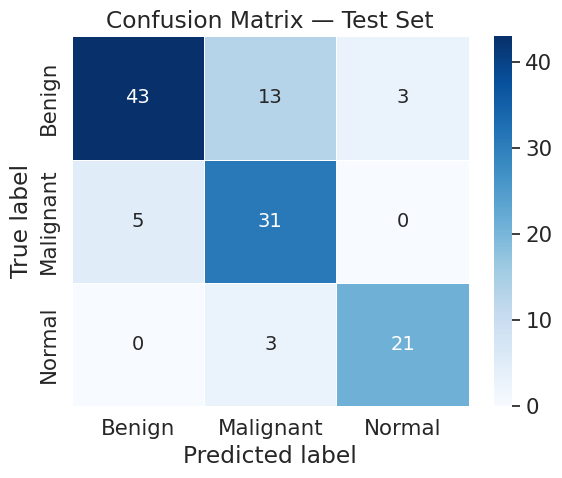


GLOBAL METRICS (TEST SET)
accuracy              : 0.7983
balanced_accuracy     : 0.8216
f1_macro              : 0.8086
f1_micro              : 0.7983
f1_weighted           : 0.8009
precision_macro       : 0.8101
recall_macro          : 0.8216

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.90      0.73      0.80        59
   Malignant       0.66      0.86      0.75        36
      Normal       0.88      0.88      0.88        24

    accuracy                           0.80       119
   macro avg       0.81      0.82      0.81       119
weighted avg       0.82      0.80      0.80       119

✅ Metrics saved to:
/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/metrics_inference.json

INFERENCE EVALUATION DONE


{'df':       idx    filename  label split  predicted_label
 0      17      18.png      2  test                2
 1      26      27.png      2  test                2
 2      33      34.png      2  test                1
 3      34      35.png      2  test                2
 4      43      44.png      2  test                2
 ..    ...         ...    ...   ...              ...
 114  1463  1068_1.png      0  test                0
 115  1464  1068_2.png      0  test                0
 116  1465  1068_3.png      0  test                1
 117  1466  1068_4.png      0  test                1
 118  1467  1068_5.png      0  test                1
 
 [119 rows x 5 columns],
 'confusion_matrix': array([[43, 13,  3],
        [ 5, 31,  0],
        [ 0,  3, 21]]),
 'metrics': {'accuracy': 0.7983193277310925,
  'balanced_accuracy': np.float64(0.8216415568110483),
  'f1_macro': 0.8085754231880794,
  'f1_micro': 0.7983193277310925,
  'f1_weighted': 0.8009422438044016,
  'precision_macro': 0.810135933806146

In [30]:
GT_CSV = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/Test.csv"
PRED_CSV = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/predicted_labels_inference.csv"
OUT_METRICS = "/content/drive/MyDrive/PROGETTO AI/ASSIGNMENT_AlwaysNeedingNaps/TASK2_completo/TASK2_INFERENCE_Test/MODELS/metrics_inference.json"



evaluate_test_inference(
    test_filenames=test_filenames,
    normal_files=normal_files,
    cls_filenames=cls_filenames,
    cls_preds=cls_preds,
    gt_csv=GT_CSV,
    out_pred_csv=PRED_CSV,
    out_metrics_json=OUT_METRICS,
)
